# Telecommunication Customer Churn — Exploratory Data Analysis

**Author:** Yakub Kayode Saheed | **Project:** Telecommunication Customer Churn Prediction

## Business problem
A telecom company loses revenue every time a customer *churns* (cancels their service). Acquiring a new customer costs far more than keeping an existing one, so the company wants to know **which customers are likely to leave** — early enough to act (a discount, a support call, a better plan).

This notebook explores the customer data to answer three questions:
1. **How many customers churn**, and is the data balanced?
2. **What distinguishes churners from non-churners** — which behaviours and contract types signal risk?
3. **What do these findings imply for modelling** — how should we prepare the data and what should the model optimise for?

The insights here directly shaped the preprocessing, feature engineering, and modelling choices in the rest of this project.

## 1. Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [15]:
# Robust path: works whether the notebook runs from the project root or the notebooks/ folder
candidates = [Path("data/raw/Telco-Customer-Churn.csv"),
              Path("../data/raw/Telco-Customer-Churn.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])

df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
df.head()

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. First look at the data

Before analysing anything, we check the shape, the columns, and their data types. This is where the first data-quality issues usually surface.

In [16]:
print("Rows, columns:", df.shape)
print()
df.info()

Rows, columns: (7043, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

Two things stand out immediately, and both matter later:

- **`TotalCharges` is stored as an `object` (text), not a number.** For a column that should be numeric, this almost always means some values aren't parseable — we investigate this in the data-quality section.
- **`customerID` is a unique identifier**, not a predictive feature. It should be dropped before modelling, or the model may try to memorise individual customers.

## 3. The target variable: who churns?

In [17]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print()
print("Churn rate: {:.1f}%".format(churn_pct["Yes"]))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\1831422256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", ax=ax[0], palette=["#4c72b0", "#dd8452"])


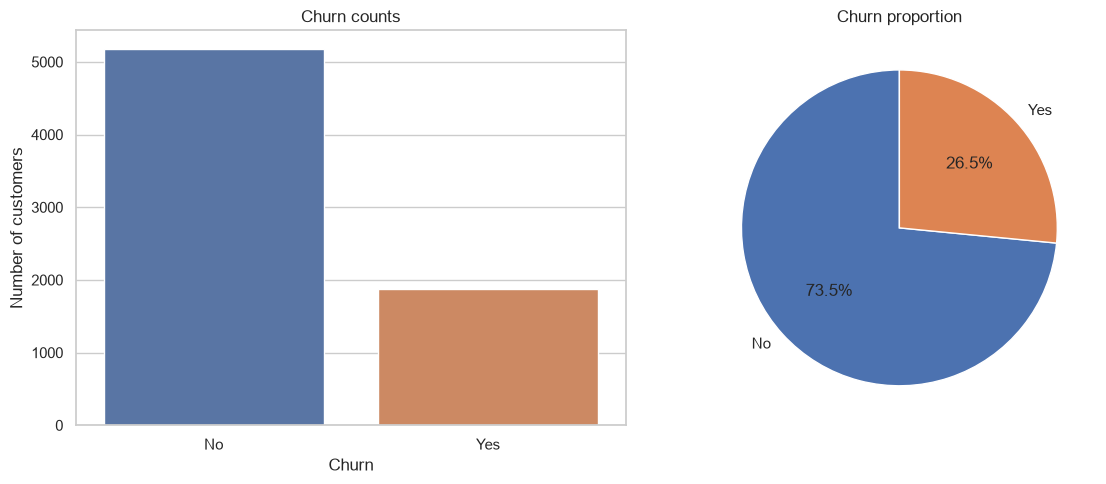

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="Churn", ax=ax[0], palette=["#4c72b0", "#dd8452"])
ax[0].set_title("Churn counts")
ax[0].set_ylabel("Number of customers")
ax[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
          colors=["#4c72b0", "#dd8452"], startangle=90)
ax[1].set_title("Churn proportion")
plt.tight_layout()
plt.show()

**Key finding — the data is imbalanced.** About **27%** of customers churned and **73%** stayed, roughly a 1-to-3 ratio.

Why this matters for modelling: a lazy model could predict "no one churns" and still be ~73% accurate — while catching *zero* churners, making it useless. This is exactly why, later in the project, we (a) do **not** rely on accuracy as the headline metric, favouring **recall** and **ROC-AUC**, and (b) use XGBoost's `scale_pos_weight` to make the model pay extra attention to the minority (churn) class.

## 4. Data quality

We check for missing values, investigate the suspicious `TotalCharges` column, and look for duplicates.

In [19]:
# TotalCharges: convert to numeric. Non-numeric entries become NaN so we can count them.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values per column (showing only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column (showing only columns with missing data):
TotalCharges    11
dtype: int64

Duplicate rows: 0


In [20]:
# Who are the rows with missing TotalCharges?
blank = df[df["TotalCharges"].isna()]
print("Rows with missing TotalCharges:", len(blank))
print("Their tenure values:", sorted(blank["tenure"].unique()))

Rows with missing TotalCharges: 11
Their tenure values: [np.int64(0)]


**Key finding — the 11 missing `TotalCharges` are all brand-new customers (`tenure = 0`).** They simply haven't been billed a full cycle yet, so their *total* charges are effectively zero. This tells us the right fix is to **fill these blanks with 0**, not to drop the rows or guess an average — a decision grounded in *why* the data is missing, not a blind imputation. (Our preprocessing module does exactly this.)

In [21]:
# Apply the reasoned fix so the rest of the analysis has clean numbers
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing TotalCharges after fix:", df["TotalCharges"].isna().sum())

Missing TotalCharges after fix: 0


## 5. Numerical features vs churn

The three numeric drivers are **tenure** (months as a customer), **MonthlyCharges**, and **TotalCharges**. We compare their distributions for churners vs non-churners — where the two groups separate, we've found a signal.

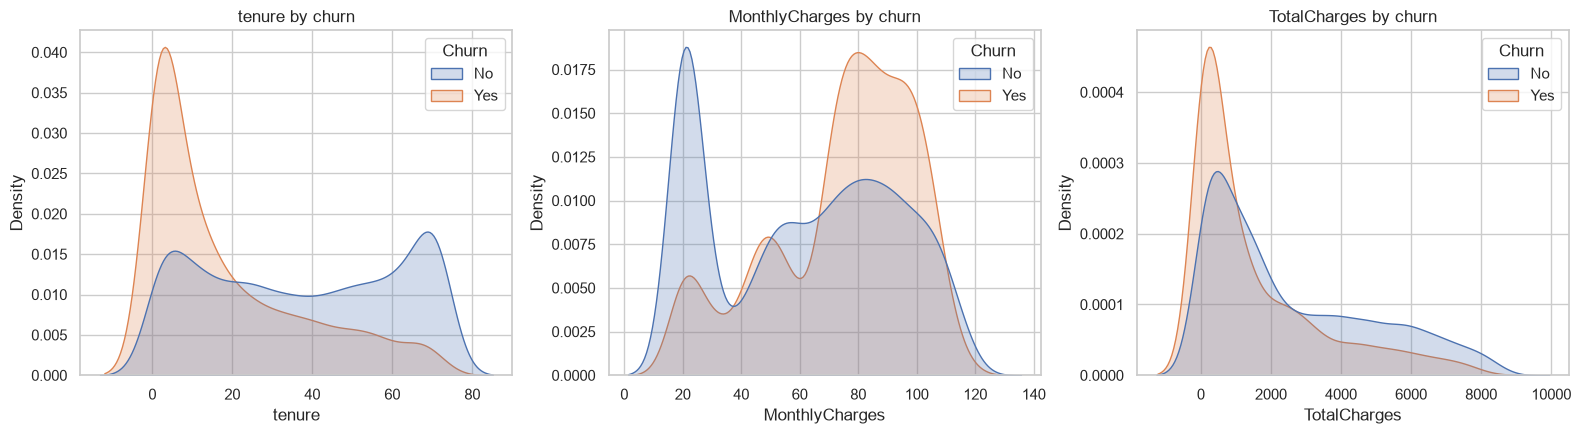

In [22]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False,
                palette=["#4c72b0", "#dd8452"], ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\1526494188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, palette=["#4c72b0", "#dd8452"], ax=ax)
C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\1526494188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, palette=["#4c72b0", "#dd8452"], ax=ax)
C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\1526494188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, palette=["#4c72b0", "#dd8452"], ax=ax)


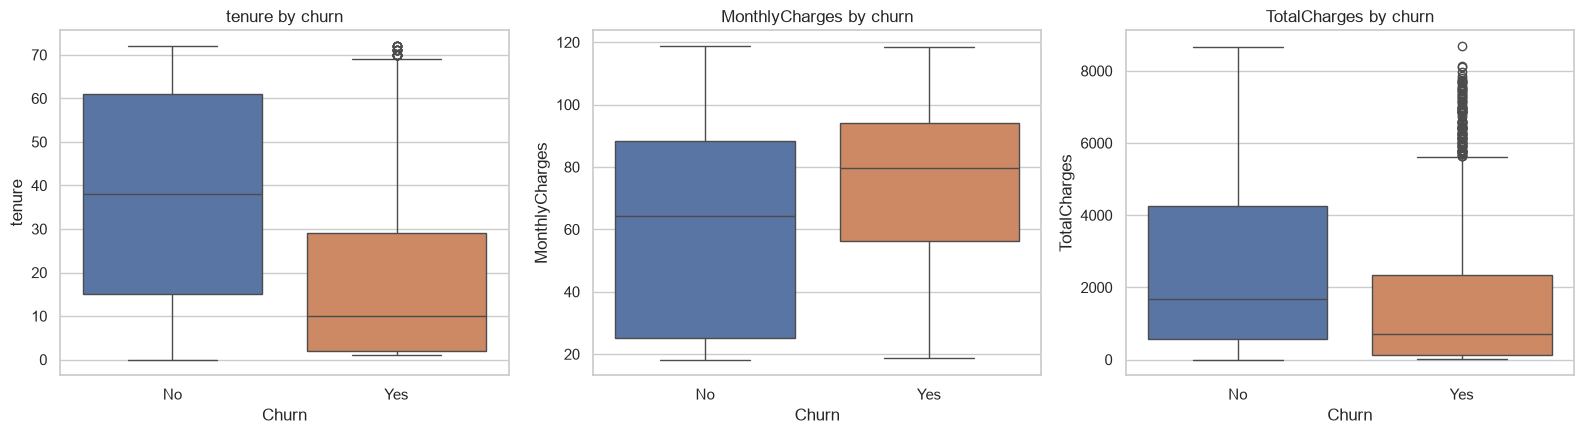

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, palette=["#4c72b0", "#dd8452"], ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

**Key findings:**
- **Tenure is the strongest numeric signal.** Churners are heavily concentrated at *low* tenure — most people who leave do so early. Long-tenured customers rarely churn.
- **Higher `MonthlyCharges` associate with more churn** — expensive plans (often fibre) push customers out.
- **`TotalCharges` is lower for churners**, which is largely a consequence of their shorter tenure (less time = less accumulated spend).

The takeaway for the business: **the first months are the danger zone.** Retention effort is best spent on newer, higher-bill customers.

## 6. Categorical features vs churn

For each categorical feature we compute the **churn rate within each category**. This is more informative than raw counts — it directly shows which groups are risky.

In [24]:
def churn_rate_by(col):
    return (df.assign(churned=(df["Churn"] == "Yes"))
              .groupby(col)["churned"].mean()
              .sort_values(ascending=False) * 100)

for c in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"--- Churn rate (%) by {c} ---")
    print(churn_rate_by(c).round(1))
    print()

--- Churn rate (%) by Contract ---
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churned, dtype: float64

--- Churn rate (%) by InternetService ---
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: churned, dtype: float64

--- Churn rate (%) by PaymentMethod ---
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: churned, dtype: float64



C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\649022158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket")
C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\649022158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket")
C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\649022158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket")
C:\Users\kayod\AppData\Local\Temp\ipykernel

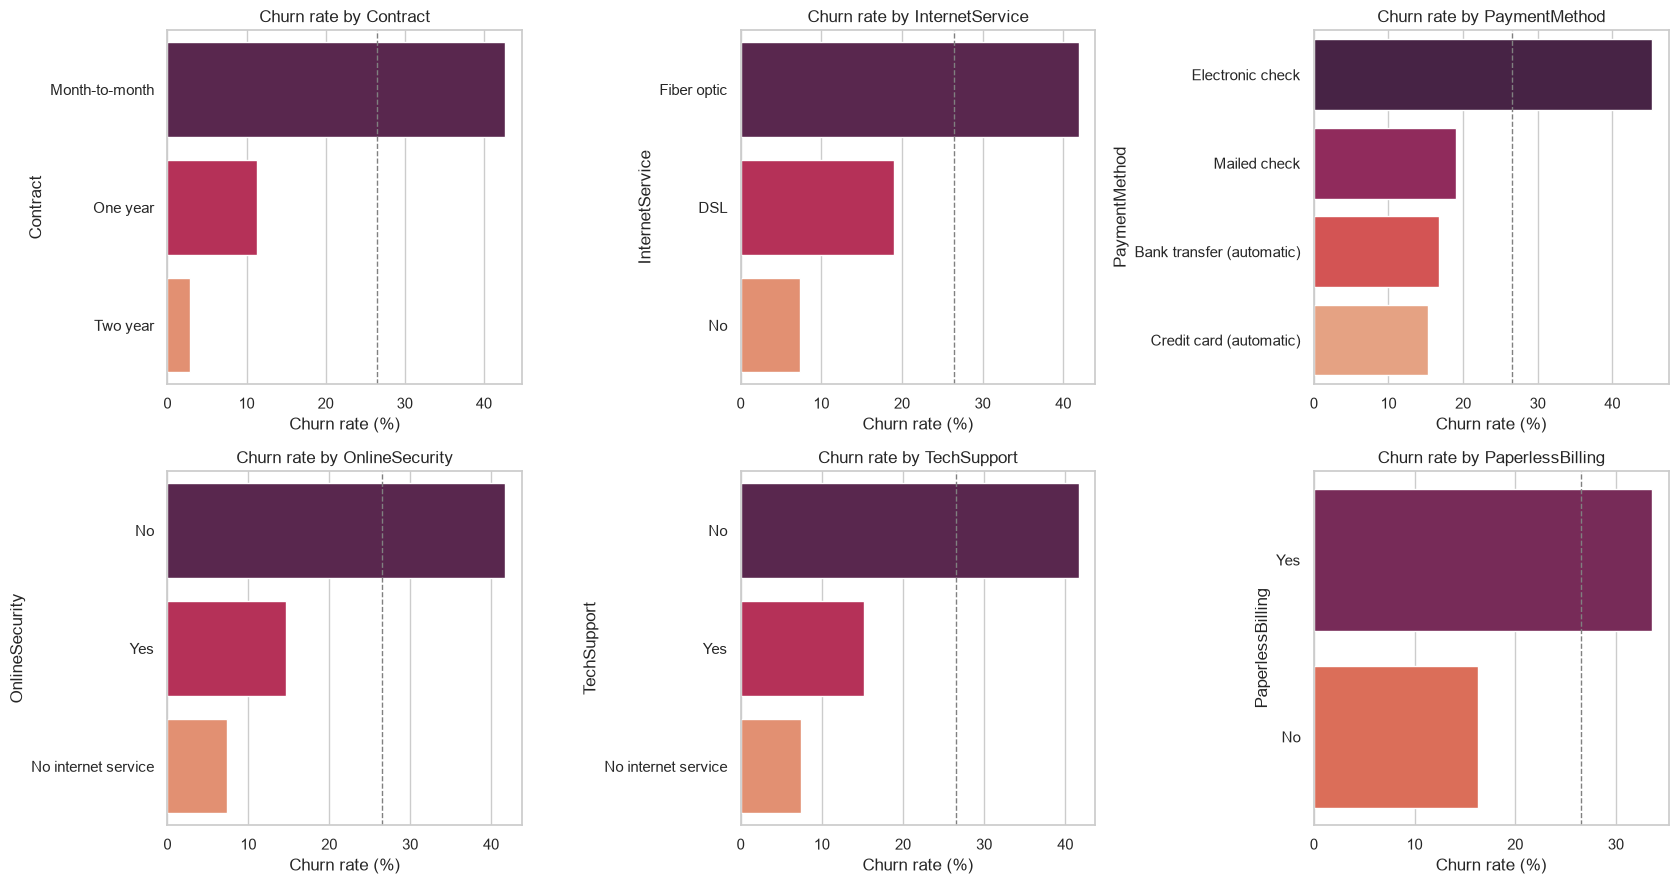

In [25]:
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "OnlineSecurity", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rates = churn_rate_by(col)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate (%)")
    ax.axvline(26.5, color="grey", linestyle="--", linewidth=1)  # overall rate
plt.tight_layout()
plt.show()

The dashed grey line marks the **overall 26.5% churn rate** — bars to its right are higher-risk-than-average groups.

**Key findings — the churn profile is remarkably clear:**
- **Contract type is the single biggest driver.** Month-to-month customers churn at ~43%, while one- and two-year contract customers churn at a fraction of that. Lock-in matters enormously.
- **Fibre-optic internet customers churn far more** than DSL or no-internet — likely a price/expectation issue.
- **Electronic-check payers churn much more** than automatic-payment users (auto-pay implies commitment and convenience).
- **Lacking add-on services** (no online security, no tech support) strongly associates with churn — these services increase "stickiness."
- **Paperless billing** correlates with higher churn (often younger, more mobile customers).

## 7. Correlations

To see how features relate to churn *numerically*, we encode the data the same way the modelling pipeline does (binary mapping + one-hot) and look at each feature's correlation with churn.

C:\Users\kayod\AppData\Local\Temp\ipykernel_21720\1345635734.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_churn.values, y=corr_with_churn.index, palette="vlag")


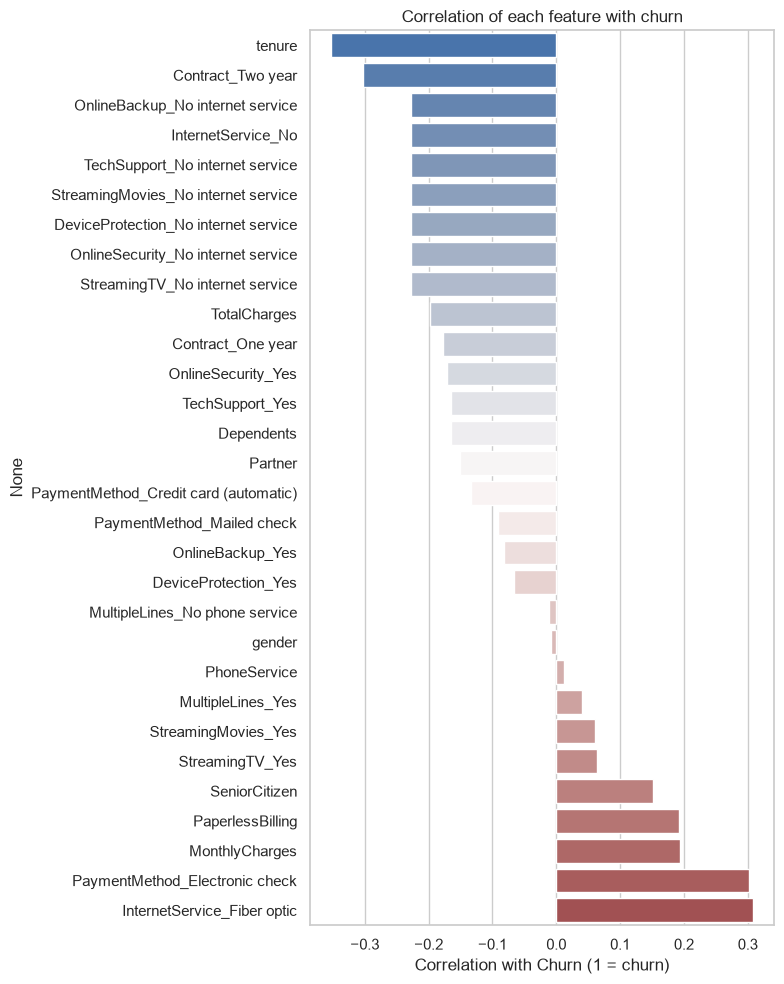

In [26]:
enc = df.drop(columns=["customerID"]).copy()
enc["Churn"] = enc["Churn"].map({"Yes": 1, "No": 0})
binary_map = {"Yes": 1, "No": 0, "Male": 1, "Female": 0}
for c in ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    enc[c] = enc[c].map(binary_map)
enc = pd.get_dummies(enc, drop_first=True).astype(float)

corr_with_churn = enc.corr()["Churn"].drop("Churn").sort_values()
plt.figure(figsize=(8, 10))
sns.barplot(x=corr_with_churn.values, y=corr_with_churn.index, palette="vlag")
plt.title("Correlation of each feature with churn")
plt.xlabel("Correlation with Churn (1 = churn)")
plt.tight_layout()
plt.show()

**Reading this chart:** features at the top (positive) push *toward* churn; features at the bottom (negative) push *away* from it.

This numerically confirms the story: **month-to-month contract, fibre-optic internet, and electronic-check payment** are the strongest churn-*increasing* signals, while **longer tenure and two-year contracts** are the strongest churn-*reducing* ones. No single feature dominates completely — which is why a model that combines many weak signals (like gradient-boosted trees) fits this problem well.

## 8. Summary — the churn story

Pulling it all together, a high-risk customer looks like this:

> **New** (low tenure), on a **month-to-month** contract, with **fibre-optic** internet, paying by **electronic check**, on **paperless billing**, and **without** add-on services like online security or tech support — typically with **higher monthly charges**.

A low-risk customer is the mirror image: long tenure, a one- or two-year contract, automatic payments, and bundled support services.

### What this means for the modelling pipeline
Every EDA finding fed a concrete decision in the rest of the project:

| Finding | Decision in the pipeline |
|---|---|
| 27% churn (imbalanced) | Optimise for **recall / ROC-AUC**, not accuracy; use `scale_pos_weight` |
| 11 blank `TotalCharges` = new customers | Fill with **0** (reasoned, not blind imputation) |
| `customerID` is an identifier | **Drop** it to prevent leakage |
| Many categorical drivers | **One-hot encode** so the model can use them |
| Signal spread across many weak features | Choose **XGBoost** (combines many weak signals well) |

The next notebook/stage tunes this model's hyperparameters to squeeze out additional performance.